# Домашнее задание 3 (продвинутая группа)

## Тема: Аналитика вакансий и факторов стоимости аренды в Москве

### Описание работы

В этой работе предстоит:
- Провести базовый EDA и очистку данных по вакансиям
- Построить вспомогательные признаки и простые визуализации
- Исследовать факторы, влияющие на цену аренды

---

## Общий формат выполнения

* Все задания разбиты на пункты с оценкой в баллах
* Под каждым заданием напишите ваш код/ответ в соответствующем блоке
* У всех графиков обязательны **подписи осей**, **заголовки** и **читаемая легенда**

---

## Импорт библиотек и настройка визуализации

**Рекомендуемые библиотеки:**

```python
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)
```

---

## 🧩 Задача 1. Аналитика по вакансиям (45 баллов)

Датасет: [скачать](https://disk.yandex.ru/d/QUa3pCKVk48cAQ)
Считайте данные с помощью `pd.read_csv`.

In [25]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)

#### 1.0. Загрузка и первичный обзор данных (1 балл)

Выведите первые 5 и последние 5 строк.
Примените `info()` и `describe()`.

> Сделайте краткий вывод по результатам анализа.

In [26]:
data = pd.read_csv("vacancies.csv")
display(data.head())
display(data.head(-5))

data.info()
data.describe()

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[]
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[]
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe..."
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[]
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']"


,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[]
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[]
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe..."
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[]
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']"
...,...,...,...,...,...,...,...,...,...,...,...
1517,1517,Data analyst / Аналитик данных (стажер),Aston,Тольятти,Нет опыта,Удаленная работа,Стажировка,"BI-аналитик, аналитик данных","{'from': 100000, 'to': 110000, 'currency': 'RU...",<p>Мы – крупная инновационная аутсорсинговая <...,"['Python', 'SQL', 'Анализ данных', 'Математиче..."
1518,1518,Data analyst / Аналитик данных (стажер),Aston,Тольятти,Нет опыта,Удаленная работа,Стажировка,"BI-аналитик, аналитик данных","{'from': 100000, 'to': 110000, 'currency': 'RU...",<p>Мы – крупная инновационная аутсорсинговая <...,"['Python', 'SQL', 'Анализ данных', 'Математиче..."
1519,1519,Senior Data Engineer,Mindbox,Москва,От 3 до 6 лет,Удаленная работа,Полная занятость,"Программист, разработчик",NaN,<p><strong>Mindbox</strong> — крупнейшая в Рос...,"['Python', 'PySpark', 'Airflow', 'Kafka', 'Del..."
1520,1520,Data Scientist AI Lab,HeadHunter,Москва,Более 6 лет,Полный день,Полная занятость,Руководитель группы разработки,NaN,"<p>Мы ищем Data Scientist в команду, которая б...","['Python', 'Machine Learning', 'Deep Learning'..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1527 entries, 0 to 1526
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          1527 non-null   int64 
 1   position_name       1527 non-null   object
 2   employer_name       1527 non-null   object
 3   area                1527 non-null   object
 4   experience          1527 non-null   object
 5   schedule            1527 non-null   object
 6   employment          1527 non-null   object
 7   professional_roles  1527 non-null   object
 8   salary              220 non-null    object
 9   description         1527 non-null   object
 10  key_skills          1527 non-null   object
dtypes: int64(1), object(10)
memory usage: 131.4+ KB


,Unnamed: 0
count,1527.000000
mean,763.000000
std,440.951244
min,0.000000
25%,381.500000
50%,763.000000
75%,1144.500000
max,1526.000000


In [ ]:
Можно сделать вывод, что у нас есть 11 признаков (включая дублирующиеся id-шники). Датасет предоставляет информацию о соискателях.

#### 1.1 Размерность датасета (1 балл)

Сколько в датасете строк и столбцов?

В датасете 1527 строк и 11 столбцов

In [27]:
data.shape

(1527, 11)

#### 1.2. Пропуски (1 балл)

Проверьте наличие пропусков и где они встречаются.

> Сделайте краткий вывод по результатам анализа. Насколько данные качественные?

Все пропуски встречаются в колонке `salary`, и их количество 1307, что является большим от общего числа строк 1527. Это говорит о том, что большая часть данных об этом признаке отсутсвует и делает его бесполезным.

In [28]:
data.isna().sum()

Unnamed: 0               0
position_name            0
employer_name            0
area                     0
experience               0
schedule                 0
employment               0
professional_roles       0
salary                1307
description              0
key_skills               0
dtype: int64

#### 1.3. Дубликаты (1 балл)

Проверьте, есть ли в датасете полные дубликаты. Если есть, удалите их.

Дубликаты отсутствуют

In [29]:
data.duplicated().sum()

0

#### 1.4. Уникальные профессиональные роли (1 балл)

Определите количество уникальных значений `professional_roles`.

36

In [30]:
data['professional_roles'].unique().__len__()

36

#### 1.5. Вакансии без требования опыта (2 балла)

Подсчитайте количество вакансий, не требующих опыта работы.

In [31]:
no_xp_vacancies = np.where(data['experience'] == 'Нет опыта')
len(no_xp_vacancies[0])

136


#### 1.6. Среднее количество навыков (2 балла)

Рассчитайте среднее количество навыков в поле `key_skills`.

In [32]:
skills_counts = data['key_skills'].dropna().apply(lambda x: len(eval(x)))
skills_counts.mean()

3.8749181401440733

#### 1.7. Валюты заработной платы (2 балла)

Определите, какие валюты используются для заработной платы (ключ currency в поле salary). Создайте столбец currency.

In [33]:
data['currency'] = data['salary'].apply(
    lambda x: str(x).split("'currency': '")[1].split("'")[0] 
    if pd.notna(x) and "'currency': '" in str(x) else None
)
print(*data['currency'].dropna().unique())

RUR KZT UZS USD EUR BYR


#### 1.8. Частота профессиональных ролей (3 балла)

Постройте таблицу частот по `professional_roles` и визуализируйте топ-10 ролей (`barplot`).

> Сделайте краткий вывод по результатам анализа.

Дата-сайентист                                          464
BI-аналитик, аналитик данных                            283
Программист, разработчик                                260
Аналитик                                                255
Другое                                                   96
Менеджер по продажам, менеджер по работе с клиентами     23
Руководитель группы разработки                           23
Руководитель проектов                                    16
Продуктовый аналитик                                     12
Руководитель отдела аналитики                            12
Name: professional_roles, dtype: int64


Text(0.5, 1.0, 'Топ-10 профессиональных ролей в датасете')

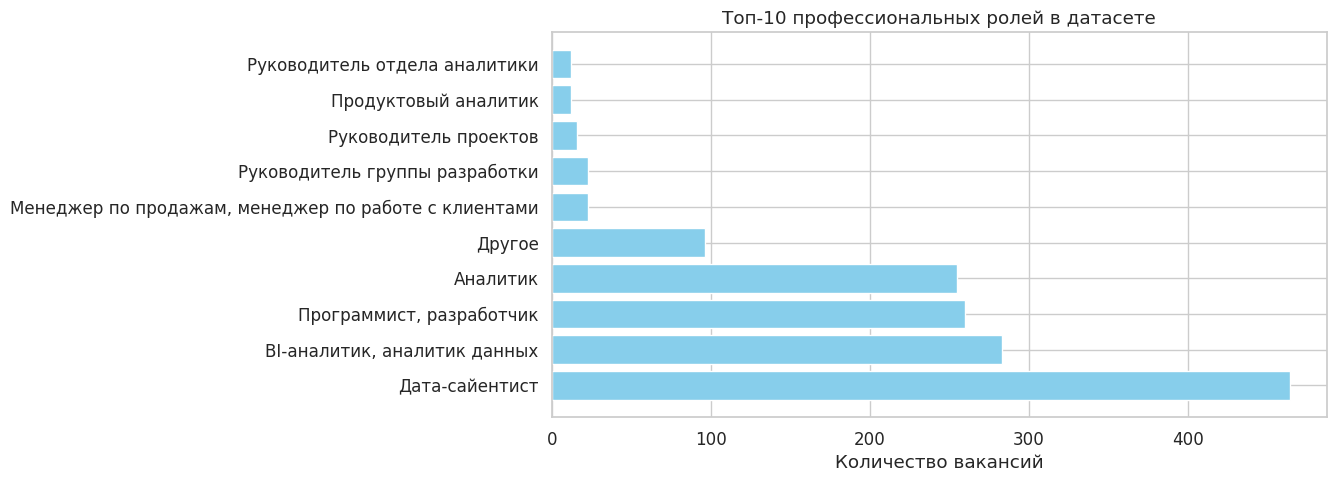

In [34]:
top10 = data['professional_roles'].value_counts().head(10)
print(top10)
plt.barh(top10.index, top10.head(10).values, color='skyblue')
plt.xlabel('Количество вакансий')
plt.title('Топ-10 профессиональных ролей в датасете')

#### 1.9. Компания-лидер (1 балл)

Какая компания лидирует по количеству вакансий с указанием заработной платы? А в целом по кол-ву вакансий, без учета наличия заработной платы в вакансии?

In [35]:
print(data[data['salary'].notna()].groupby('employer_name').size().idxmax())
print(data[data['salary'].notna()].groupby('employer_name').size().max())

Aston
29


#### 1.10. Создание столбца salary_num (2 балла)

Создайте столбец salary_num. Рассчитайте его, используя столбец salary. Если в этом столбце указана вилка зарплаты, используйте среднее значение между from и to. Если указано только одно из значений (from или to), используйте его.

In [39]:
import ast

def calculate_salary_simple(salary_str):
    if pd.isna(salary_str):
        return None
    
    try:
        salary_dict = ast.literal_eval(str(salary_str))
        
        salary_from = salary_dict.get('from')
        salary_to = salary_dict.get('to')
        
        if salary_from == 'null' or salary_from == 'None':
            salary_from = None
        if salary_to == 'null' or salary_to == 'None':
            salary_to = None
        
        try:
            if salary_from is not None:
                salary_from = float(salary_from)
        except (TypeError, ValueError):
            salary_from = None
            
        try:
            if salary_to is not None:
                salary_to = float(salary_to)
        except (TypeError, ValueError):
            salary_to = None
        
        if salary_from is not None and salary_to is not None:
            return (salary_from + salary_to) / 2
        elif salary_from is not None:
            return salary_from
        elif salary_to is not None:
            return salary_to
        else:
            return None
            
    except:
        return None

data['salary_num'] = data['salary'].apply(calculate_salary_simple)
data.head()

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills,currency,salary_num
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[],RUR,372500.0
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[],KZT,800000.0
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe...",None,NaN
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[],None,NaN
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']",KZT,950000.0


In [40]:
rur_data = data[data['currency'] == 'RUR']
print(f"Средняя заработная плата среди вакансий в рублях: {rur_data['salary_num'].mean()}")
print(f"Медианная заработная плата среди вакансий в рублях: {rur_data['salary_num'].median()}")

top_10_roles = data['professional_roles'].value_counts().head(10).index

top_roles_rur = rur_data[rur_data['professional_roles'].isin(top_10_roles)]

salary_by_role = top_roles_rur.groupby('professional_roles')['salary_num'].agg(['mean', 'median']).round(2)

print("Средняя и медианная зарплата по топ-10 позициям в рублях:")
print(salary_by_role)

Средняя заработная плата среди вакансий в рублях: 212395.02762430938
Медианная заработная плата среди вакансий в рублях: 200000.0
Средняя и медианная зарплата по топ-10 позициям в рублях:
                                                         mean    median
professional_roles                                                     
BI-аналитик, аналитик данных                        164552.50  120000.0
Аналитик                                            180396.00  150000.0
Дата-сайентист                                      210203.12  200000.0
Другое                                              301923.08  372500.0
Менеджер по продажам, менеджер по работе с клие...  207500.00  207500.0
Программист, разработчик                            277259.26  300000.0
Продуктовый аналитик                                152500.00  152500.0
Руководитель группы разработки                      150000.00  150000.0


#### 1.11. Средняя и медианная зарплата (2 балла)

Какая средняя заработная плата среди вакансий в рублях? А средняя и медианная заработная плата по 10 наиболее частым позициям в датасете в рублях?

#### 1.12. Требование знания Python (3 балла)

Создайте столбец is_python_requirement, который принимает значение 1, если в key_skills присутствует python (учитывайте написание в любом регистре, а также вхождения подстроки python). Какой процент вакансий требует знания python?

In [41]:
import re

def check_python_simple(skills_str):
    skills_text = str(skills_str).lower()
    if re.search(r'python', skills_text):
        return 1
    return 0

data['is_python_requirement'] = data['key_skills'].apply(check_python_simple)

total = len(data)
python_count = data['is_python_requirement'].sum()

print(f"Процент вакансий с требованием Python: {round((python_count / total) * 100)}%")

Процент вакансий с требованием Python: 41%


#### 1.13. Группировка по нескольким признакам (3 балла)

Сгруппируйте по столбцам experience, schedule, employment, is_python_requirement (сразу по четырем столбцам). Найдите по каждой группе:
- количество опубликованных вакансий
- количество компаний, которые опубликовали вакансии
- среднюю заработную плату среди вакансий с указанием зарплаты в рублях

In [42]:
grouped_stats = data.groupby(['experience', 'schedule', 'employment', 'is_python_requirement']).agg({
    'employer_name': 'count',
    'employer_name': 'nunique',
    'salary_num': lambda x: x[(data.loc[x.index, 'currency'] == 'RUR') & (x.notna())].mean()
}).reset_index()


grouped_stats = grouped_stats.sort_values('employer_name', ascending=False)
display(grouped_stats.head(20))

,experience,schedule,employment,is_python_requirement,employer_name,salary_num
33,От 3 до 6 лет,Полный день,Полная занятость,0,132,340909.090909
21,От 1 года до 3 лет,Полный день,Полная занятость,0,132,224308.823529
34,От 3 до 6 лет,Полный день,Полная занятость,1,105,339181.250000
22,От 1 года до 3 лет,Полный день,Полная занятость,1,104,140312.500000
37,От 3 до 6 лет,Удаленная работа,Полная занятость,1,63,238552.631579
36,От 3 до 6 лет,Удаленная работа,Полная занятость,0,56,336730.769231
27,От 1 года до 3 лет,Удаленная работа,Полная занятость,1,37,177500.000000
26,От 1 года до 3 лет,Удаленная работа,Полная занятость,0,36,178333.333333
2,Более 6 лет,Полный день,Полная занятость,0,30,318000.000000
8,Нет опыта,Полный день,Полная занятость,0,17,67571.428571





#### 1.14. Подсчет количества навыков (3 балла)

Создайте столбец count_skills. В нём должна быть длина списка, который находится в столбце key_skills. Обратите внимание, что изначально столбец key_skills - строка, например, '[]'. Подумайте, как превратить её в список и посчитать его длину.

In [43]:
def count_skills(skills_str):
    if pd.isna(skills_str):
        return 0
    
    skills_str = str(skills_str)

    if skills_str == '[]' or skills_str == 'None' or skills_str == 'nan':
        return 0

    if skills_str.startswith('[') and skills_str.endswith(']'):
        content = skills_str[1:-1].strip()
        if not content:
            return 0

        return len([x for x in content.split("',") if x.strip()])
    
    return 0

data['count_skills'] = data['key_skills'].apply(count_skills)
data.head(10)

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills,currency,salary_num,is_python_requirement,count_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[],RUR,372500.0,0,0
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[],KZT,800000.0,0,0
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe...",None,NaN,1,11
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[],None,NaN,0,0
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']",KZT,950000.0,0,2
5,5,Data Scientist,China Good Car,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Дата-сайентист,"{'from': 450000, 'to': 'null', 'currency': 'KZ...",<strong>Обязанности:</strong> <p>- Проектирова...,"['Python', 'Обработка естественного языка (NLP...",KZT,450000.0,1,15
6,6,Стажер Data Scientist,WILDBERRIES,Москва,Нет опыта,Полный день,Стажировка,Дата-сайентист,NaN,<p>Начни свою карьеру в Wildberries!</p> <p>Мы...,[],None,NaN,0,0
7,7,Стажер - Data Scientist,Эр-1,Пермь,Нет опыта,Удаленная работа,Стажировка,Дата-сайентист,NaN,<p><strong>R1</strong> — это новый взгляд на п...,[],None,NaN,0,0
8,8,Аналитик данных/ data analyst,Skillzania,Москва,От 1 года до 3 лет,Удаленная работа,Полная занятость,"BI-аналитик, аналитик данных","{'from': 80000, 'to': 'null', 'currency': 'RUR...",<p><strong>Группа компаний SKILLZANIA это:<br ...,[],RUR,80000.0,0,0
9,9,Аналитик данных/ Data analyst,Bereke Bank,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Обязанности:</strong> <ul> <li>Поддерж...,[],None,NaN,0,0




#### 1.15. Описание без HTML-тегов (3 балла)

Создайте столбец filtered_descr, в котором должны быть описания (description) в символах без учета HTML-тегов ("<...>"). Напишите для этого функцию get_descr. Можете использовать регулярные выражения или самостоятеьно написанный код.


In [44]:
import re

def get_descr(descr):
    if pd.isna(descr):
        return ""
    
    descr_str = str(descr)

    clean_descr = re.sub(r'<[^>]+>', '', descr_str)
    
    clean_descr = re.sub(r'\s+', ' ', clean_descr)
    clean_descr = clean_descr.strip()
    
    return clean_descr

data['filtered_descr'] = data['description'].apply(get_descr)
data.head(3)

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills,currency,salary_num,is_python_requirement,count_skills,filtered_descr
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[],RUR,372500.0,0,0,В наших командах разрабатывают эффективные тех...
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[],KZT,800000.0,0,0,ОбязанностиИзвлечение данных из различных исто...
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe...",None,NaN,1,11,"About Us: Welcome to “IMAN TECH”, where innova..."


#### 1.16. Таблица корреляций (1 балл)

Постройте таблицу корреляций с тремя переменными: `salary_num`, `len_descr`, `count_skills`, где `len_descr` - новый столбец, равный длине строки в столбце `filtered_descr`.

In [46]:
data['len_descr'] = data['filtered_descr'].apply(len)

correlation_data = data[['salary_num', 'len_descr', 'count_skills']].copy()

correlation_data_clean = correlation_data.dropna()

correlation_matrix = correlation_data_clean.corr()

print(correlation_matrix.round(3))

              salary_num  len_descr  count_skills
salary_num         1.000      0.001        -0.012
len_descr          0.001      1.000         0.153
count_skills      -0.012      0.153         1.000


#### 1.17. Тепловая карта корреляций (1 балл)

Постройте тепловую карту из таблицы из предыдущего пункта.

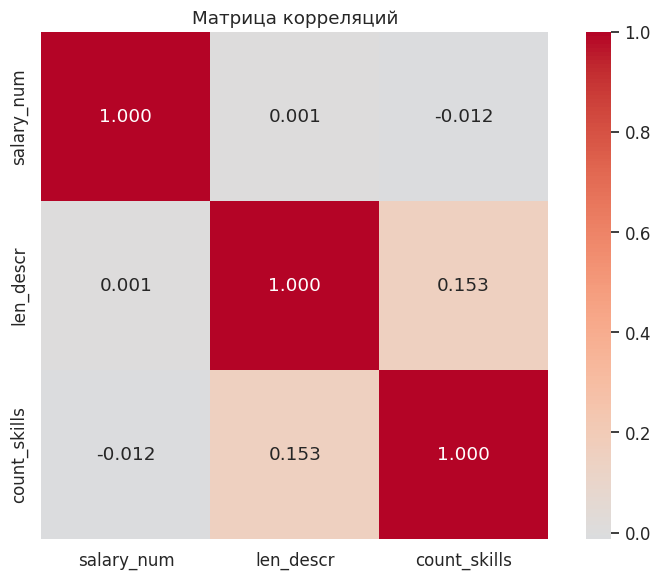

In [47]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.3f')

plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

#### 1.18. Топ-10 требуемых навыков (3 балла)

Какие скиллы чаще всего требуются? Выведите топ-10 требуемых скиллов.

In [48]:
skills_df = data['key_skills'].dropna().apply(
    lambda x: ast.literal_eval(str(x)) if pd.notna(x) else []
)

all_skills_series = skills_df.explode()

top_10_skills = all_skills_series.value_counts().head(10)

total_with_skills = skills_df.shape[0]

for i, (skill, count) in enumerate(top_10_skills.items(), 1):
    percentage_total = (count / len(data)) * 100
    percentage_with_skills = (count / total_with_skills) * 100
    print(f"{i:2d}. {skill:<30} {count:4d} вакансий ({percentage_total:.1f}% от всех, {percentage_with_skills:.1f}% от вакансий с навыками)")

 1. Python                          633 вакансий (41.5% от всех, 41.5% от вакансий с навыками)
 2. SQL                             574 вакансий (37.6% от всех, 37.6% от вакансий с навыками)
 3. ETL                             154 вакансий (10.1% от всех, 10.1% от вакансий с навыками)
 4. Big Data                        146 вакансий (9.6% от всех, 9.6% от вакансий с навыками)
 5. Hadoop                          118 вакансий (7.7% от всех, 7.7% от вакансий с навыками)
 6. PostgreSQL                      113 вакансий (7.4% от всех, 7.4% от вакансий с навыками)
 7. DWH                             111 вакансий (7.3% от всех, 7.3% от вакансий с навыками)
 8. Clickhouse                      102 вакансий (6.7% от всех, 6.7% от вакансий с навыками)
 9. Английский язык                  93 вакансий (6.1% от всех, 6.1% от вакансий с навыками)
10. Математический анализ            90 вакансий (5.9% от всех, 5.9% от вакансий с навыками)


#### 1.19. Распределение зарплаты (3 балла)

Постройте гистограмму распределения зарплаты среди вакансий в рублях.

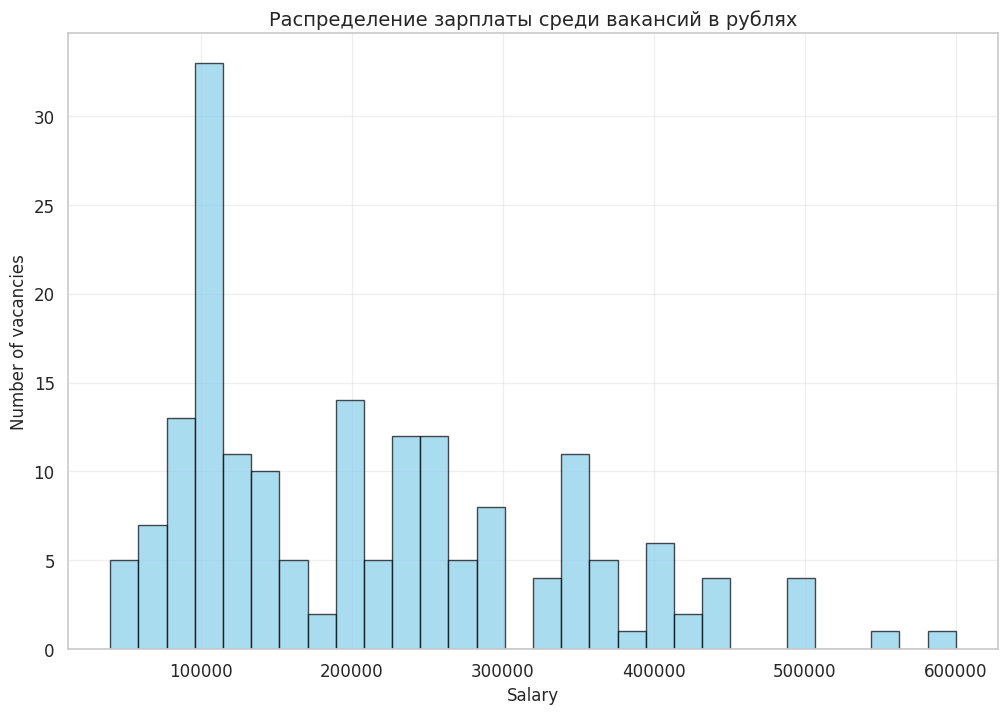

In [51]:
rur_salaries = data[data['currency'] == 'RUR']['salary_num'].dropna()

plt.figure(figsize=(12, 8))
plt.hist(rur_salaries, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Salary', fontsize=12)
plt.ylabel('Number of vacancies', fontsize=12)
plt.title('Распределение зарплаты среди вакансий в рублях', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

#### 1.20. Boxplot зарплаты по опыту работы (3 балла)

Постройте boxplot зарплаты (среди вакансий в рублях) с группировкой по полю experience.

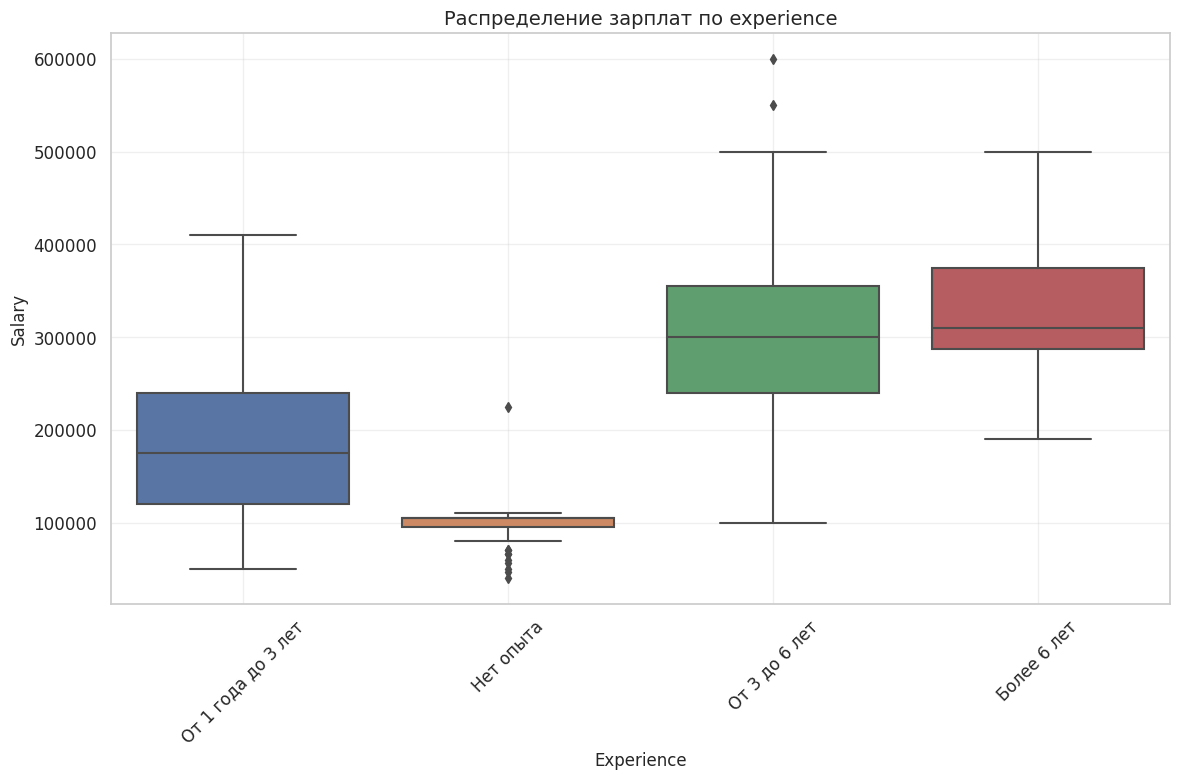

In [55]:
rur_data = data[data['currency'] == 'RUR'].dropna(subset=['salary_num'])

plt.figure(figsize=(12, 8))
sns.boxplot(data=rur_data, x='experience', y='salary_num')
plt.title('Распределение зарплат по experience', fontsize=14)
plt.xlabel('Experience', fontsize=12)
plt.ylabel('Salary', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 1.21. Собственный исследовательский вопрос (до 3 баллов)

Попробуйте ответить на какой-нибудь вопрос по данным, не заданный ранее. Никак не ограничиваем вашу фантазию и покажите весь уровень вашего владения `pandas`.


Исследовательский вопрос: Влияет ли знание Python на зарплату?

Cредние зарплаты:
С требованием Python: 188327 руб.
Без требования Python: 239578 руб.

Разница: -51251 руб. (-21.4%)


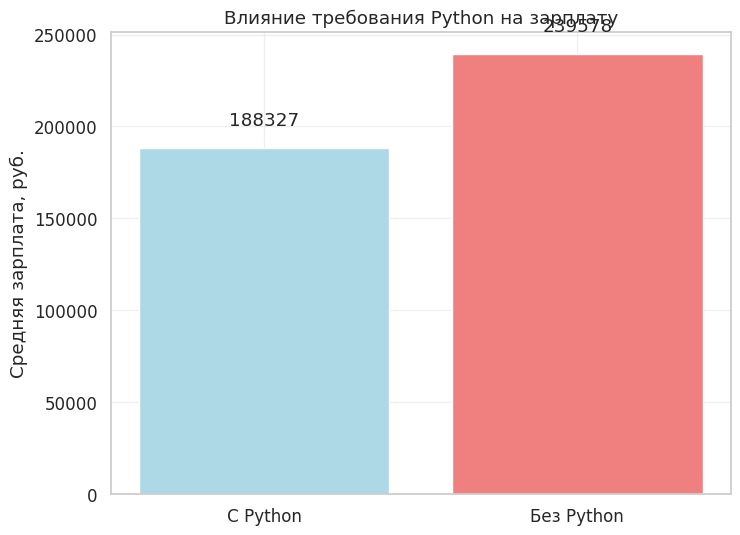

In [58]:
python_salaries = data[(data['currency'] == 'RUR') & (data['is_python_requirement'] == 1)]['salary_num'].mean()
non_python_salaries = data[(data['currency'] == 'RUR') & (data['is_python_requirement'] == 0)]['salary_num'].mean()

print("Cредние зарплаты:")
print(f"С требованием Python: {python_salaries:.0f} руб.")
print(f"Без требования Python: {non_python_salaries:.0f} руб.")

difference = python_salaries - non_python_salaries
percent = (difference / non_python_salaries) * 100

print(f"\nРазница: {difference:.0f} руб. ({percent:.1f}%)")

plt.figure(figsize=(8, 6))

categories = ['С Python', 'Без Python']
salaries = [python_salaries, non_python_salaries]

plt.bar(categories, salaries, color=['lightblue', 'lightcoral'])
plt.ylabel('Средняя зарплата, руб.')
plt.title('Влияние требования Python на зарплату')
plt.grid(True, alpha=0.3)

for i, v in enumerate(salaries):
    plt.text(i, v + 10000, f'{v:.0f}', ha='center', va='bottom')

plt.show()

Исследование показывает, что вакансии без знания python предлагают более высокую среднюю зарплату.

---

## Задача 2. 25 баллов

Работаем с датасетом https://disk.yandex.ru/d/P6u1Za-nnmtwPA
Скачайте его.

Оцениваем факторы, которые влияют на цену на аренду в Москве.

Описание столбцов:

| Переменная     | Описание                                     |
|----------------|----------------------------------------------|
| metro          | ближайшая станция метро                      |
| price          | цена за аренду                               |
| minutes        | расстояние до метро в минутах                |
| way            | путь до метро (пешком или на транспорте)     |
| views          | просмотры квартиры                           |
| provider       | кто сдает квартиру (собственник и др.)       |
| fee_percent    | процент, который получает риелтор            |
| storey         | этаж                                         |
| storeys        | число этажей в здании                        |
| living_area    | жилая площадь                                |
| kitchen_area   | площадь кухни                                |
| total_area     | общая площадь                                |



In [59]:
import pandas as pd
df = pd.read_csv('rent.csv', index_col=0)

#### 2.1. Первичный обзор данных (1 балл)

Отобразите первые 5 и последние 5 строк датасета.

In [62]:
display(df.head(-5))

,metro,price,way,views,provider,fee_percent,storey,minutes,storeys,living_area,kitchen_area,total_area
0,Planernaia,45000,walk,513,realtor,50,7,10,12,19,8,38
1,VDNKh,50000,walk,389,realtor,50,16,10,16,18,8,41
2,Alekseevskaia,50000,walk,483,realtor,50,5,3,12,19,5,33
3,Sviblovo,38000,walk,414,realtor,50,3,15,5,37,37,37
4,Rimskaia,55999,walk,360,realtor,99,6,7,17,21,10,40
...,...,...,...,...,...,...,...,...,...,...,...,...
1436,Paveletckaia,20000,walk,38,realtor,50,7,6,10,22,11,42
1437,Altufevo,37000,walk,21,realtor,30,7,10,12,21,8,38
1438,Tcaritcyno,45000,transport,30,owner,0,5,5,15,25,14,52
1439,Shchelkovskaia,47000,walk,25,realtor,50,4,12,14,21,10,38


#### 2.2. Описательные статистики (1 балл)

Посчитайте описательные статистики числовых переменных с помощью describe(). Есть ли какие-то инсайты?

> Ответ текстом

- Максимальная этажность - 13217, максимальный этаж - 613
- Средняя цена - 43370, медиана - 38000. Распределение скошено вправо

In [63]:
df.describe()

,price,views,fee_percent,storey,minutes,storeys,living_area,kitchen_area,total_area
count,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000
mean,43770.738589,417.917012,37.949516,7.089903,8.753804,22.545643,20.585754,11.369986,37.265560
std,33232.151532,936.532913,26.893347,16.511552,4.710759,347.279854,5.608993,8.083777,6.143386
min,14000.000000,4.000000,0.000000,1.000000,0.000000,1.000000,6.000000,3.000000,1.000000
25%,29000.000000,38.000000,0.000000,4.000000,5.000000,9.000000,18.000000,7.000000,34.000000
50%,38000.000000,103.000000,50.000000,6.000000,7.000000,12.000000,20.000000,10.000000,37.000000
75%,45000.000000,414.000000,50.000000,9.000000,12.000000,16.000000,21.000000,10.000000,40.000000
max,500000.000000,5174.000000,100.000000,613.000000,47.000000,13217.000000,37.000000,37.000000,57.000000


#### 2.3. Статистики категориальных переменных (1 балл)

Посчитайте статистики по категориальным переменным. Сколько уникальных значений у переменной metro?

In [68]:
display(df.select_dtypes(include=['object']).describe())
print(df['metro'].nunique())

,metro,way,provider
count,1446,1446,1446
unique,119,2,7
top,Planernaia,walk,realtor
freq,126,1331,615


119


#### 2.4. Пропуски (1 балл)

Проверьте, есть ли в датасете пропуски. Если есть, укажите в каких столбцах они встречаются и сколько их.

In [69]:
missing_values = df.isnull().sum()
print(missing_values)

metro           0
price           0
way             0
views           0
provider        0
fee_percent     0
storey          0
minutes         0
storeys         0
living_area     0
kitchen_area    0
total_area      0
dtype: int64


#### 2.5. Дубликаты (2 балла)

Проверьте, есть ли в датасете полные дубликаты. Если есть, удалите их.

In [71]:
duplicates_count = df.duplicated().sum()
print(duplicates_count)
df = df.drop_duplicates()
print(df.duplicated().sum())

1201
0


#### 2.6. Анализ переменной provider (3 балла)

Определите количество уникальных значений у переменной provider. Есть ли со значениями этой переменной какие-нибудь проблемы? Если да, то как их исправить?

> Ответ текстом

Дублирование значений, разные языки.
Как исправить? Привести все к нижнему регистру, объединить одинаковые значения

In [74]:
provider_stats = df['provider'].value_counts()
print(provider_stats)
print(df['provider'].nunique())

agency                           90
Застройщик                       68
owner                            38
realtor                          16
realtor                          15
agency                           10
agency                            8
Name: provider, dtype: int64
7


#### 2.7. Гистограммы распределения (2 балла)

Постройте гистограммы распределения всех числовых переменных. Обязательно подпишите график и оси.

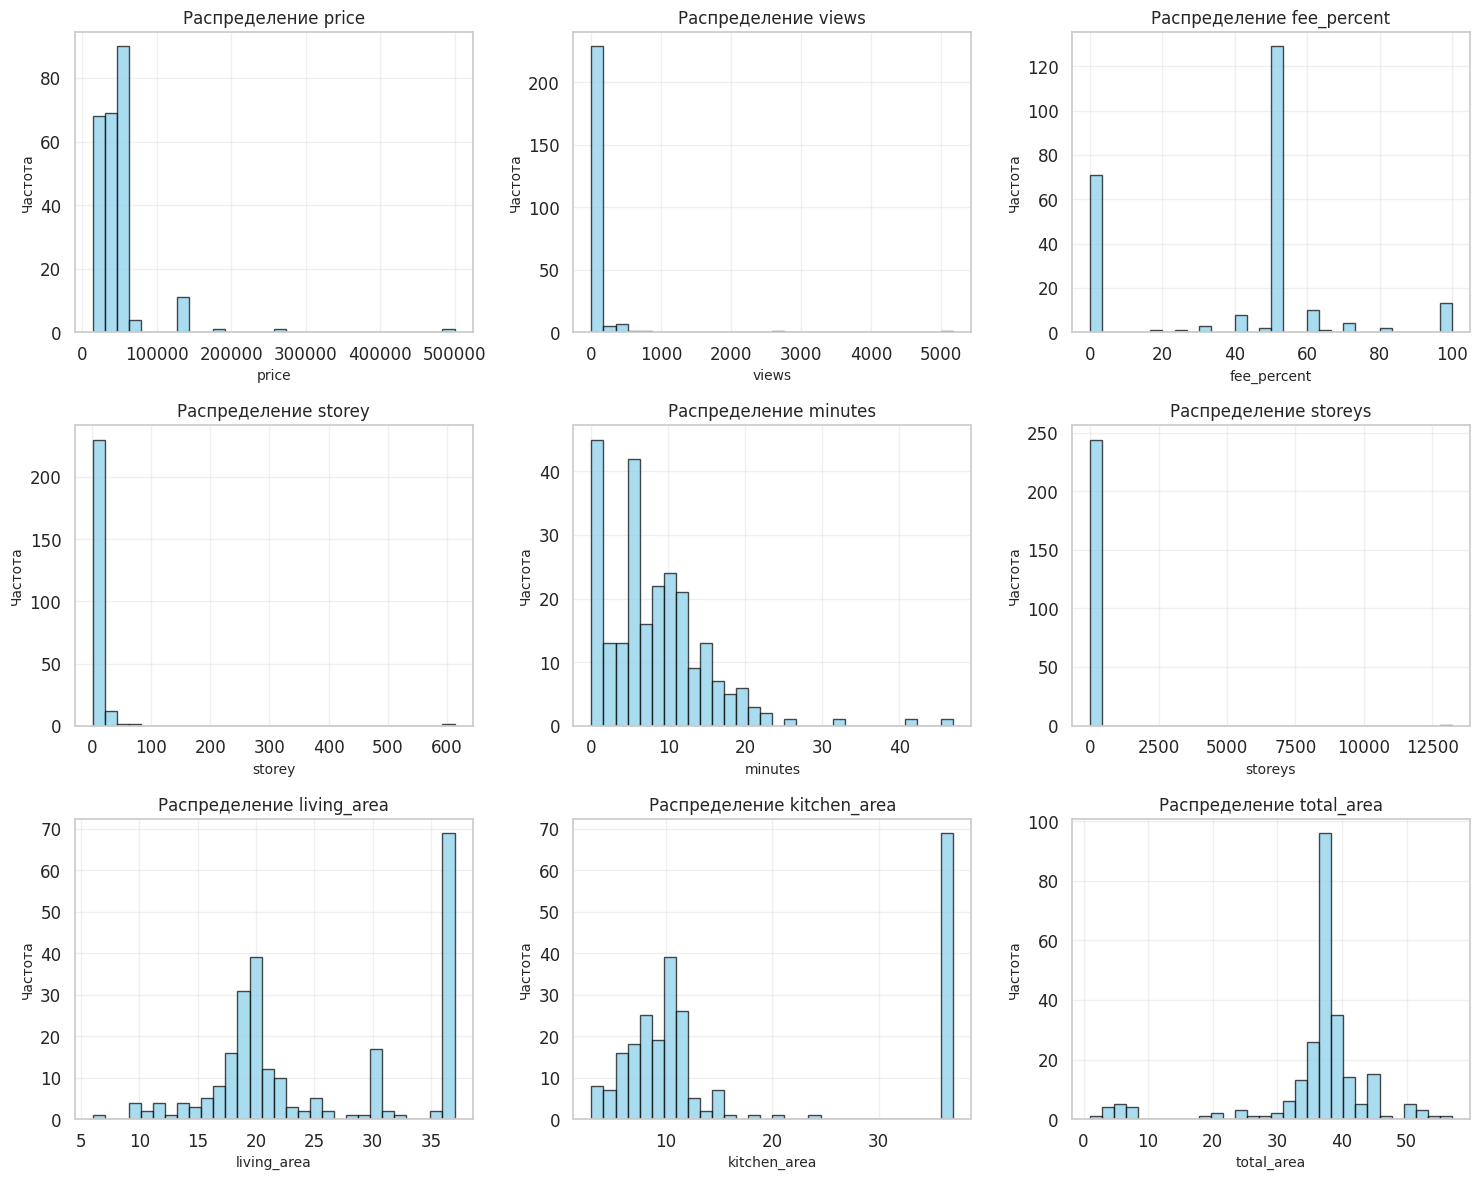

In [79]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, column in enumerate(numeric_columns):
    if i < len(axes):
        df[column].hist(bins=30, ax=axes[i], color='skyblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Распределение {column}', fontsize=12)
        axes[i].set_xlabel(column, fontsize=10)
        axes[i].set_ylabel('Частота', fontsize=10)
        axes[i].grid(True, alpha=0.3)

for i in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#### 2.8. Функция для scatter plot (4 балла)

Напишите функцию, которая принимает на вход датасет, названия столбцов, название графика и осей и рисует scatter plot. Нарисуйте с её помощью не менее трёх scatterplot.

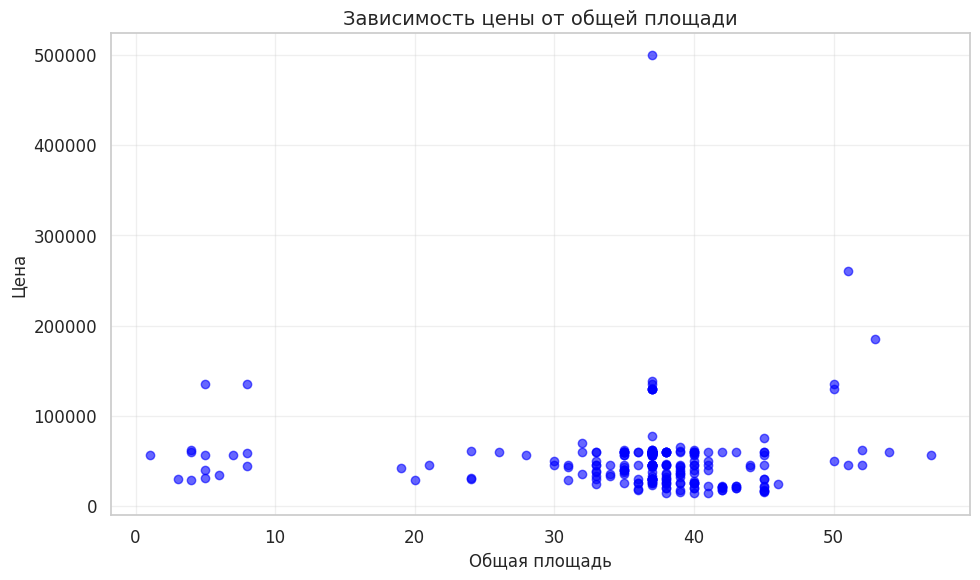

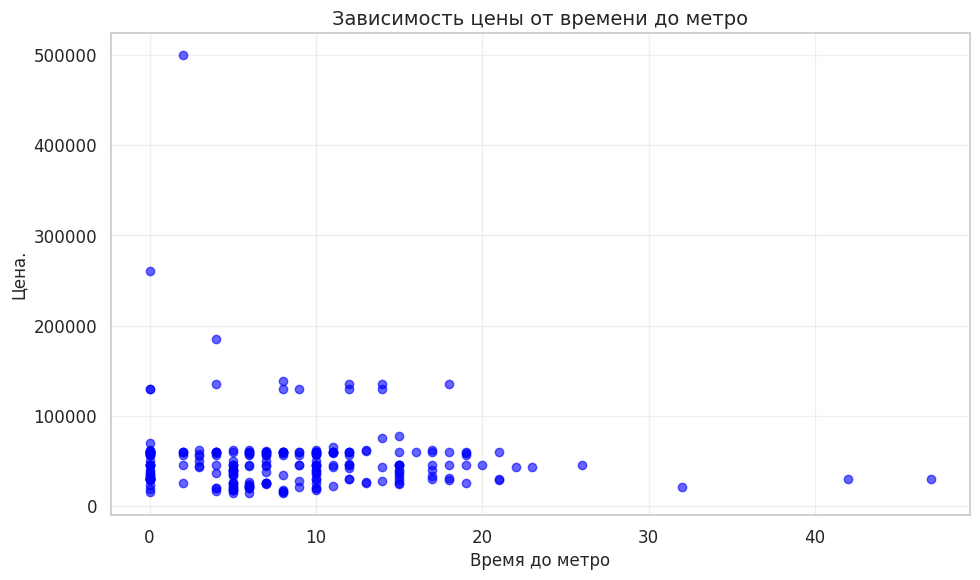

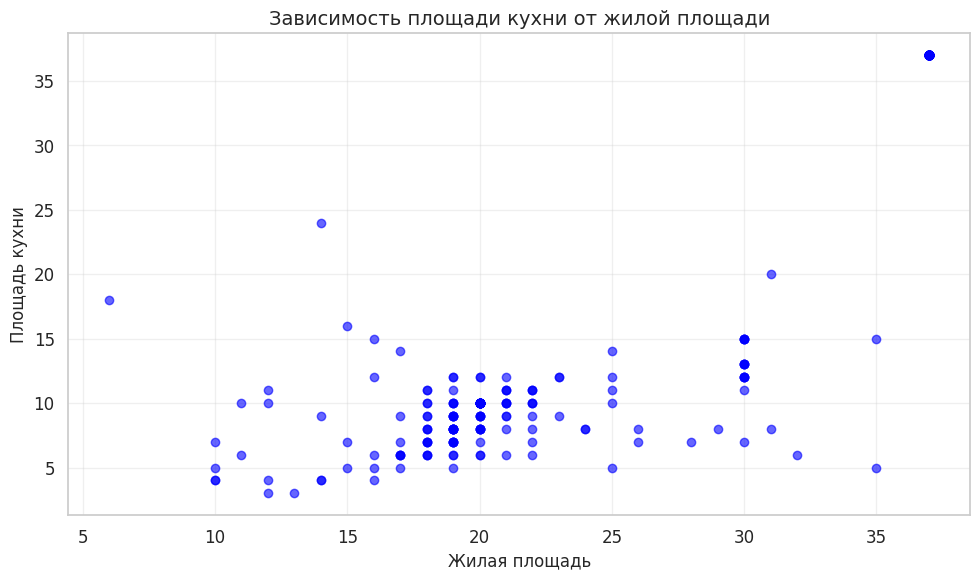

In [82]:
def plot_scatter(dataset, x_col, y_col, title, x_label, y_label):
    plt.figure(figsize=(10, 6))
    plt.scatter(dataset[x_col], dataset[y_col], alpha=0.6, color='blue')
    plt.title(title, fontsize=14)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_scatter(df, 'total_area', 'price', 'Зависимость цены от общей площади', 'Общая площадь', 'Цена')

plot_scatter(df, 'minutes', 'price', 'Зависимость цены от времени до метро', 'Время до метро', 'Цена.')

plot_scatter(df, 'living_area', 'kitchen_area', 'Зависимость площади кухни от жилой площади', 'Жилая площадь', 'Площадь кухни')

#### 2.9. Pairplot (1 балл)

Постройте scatterplot всех пар переменных с помощью sns.pairplot.

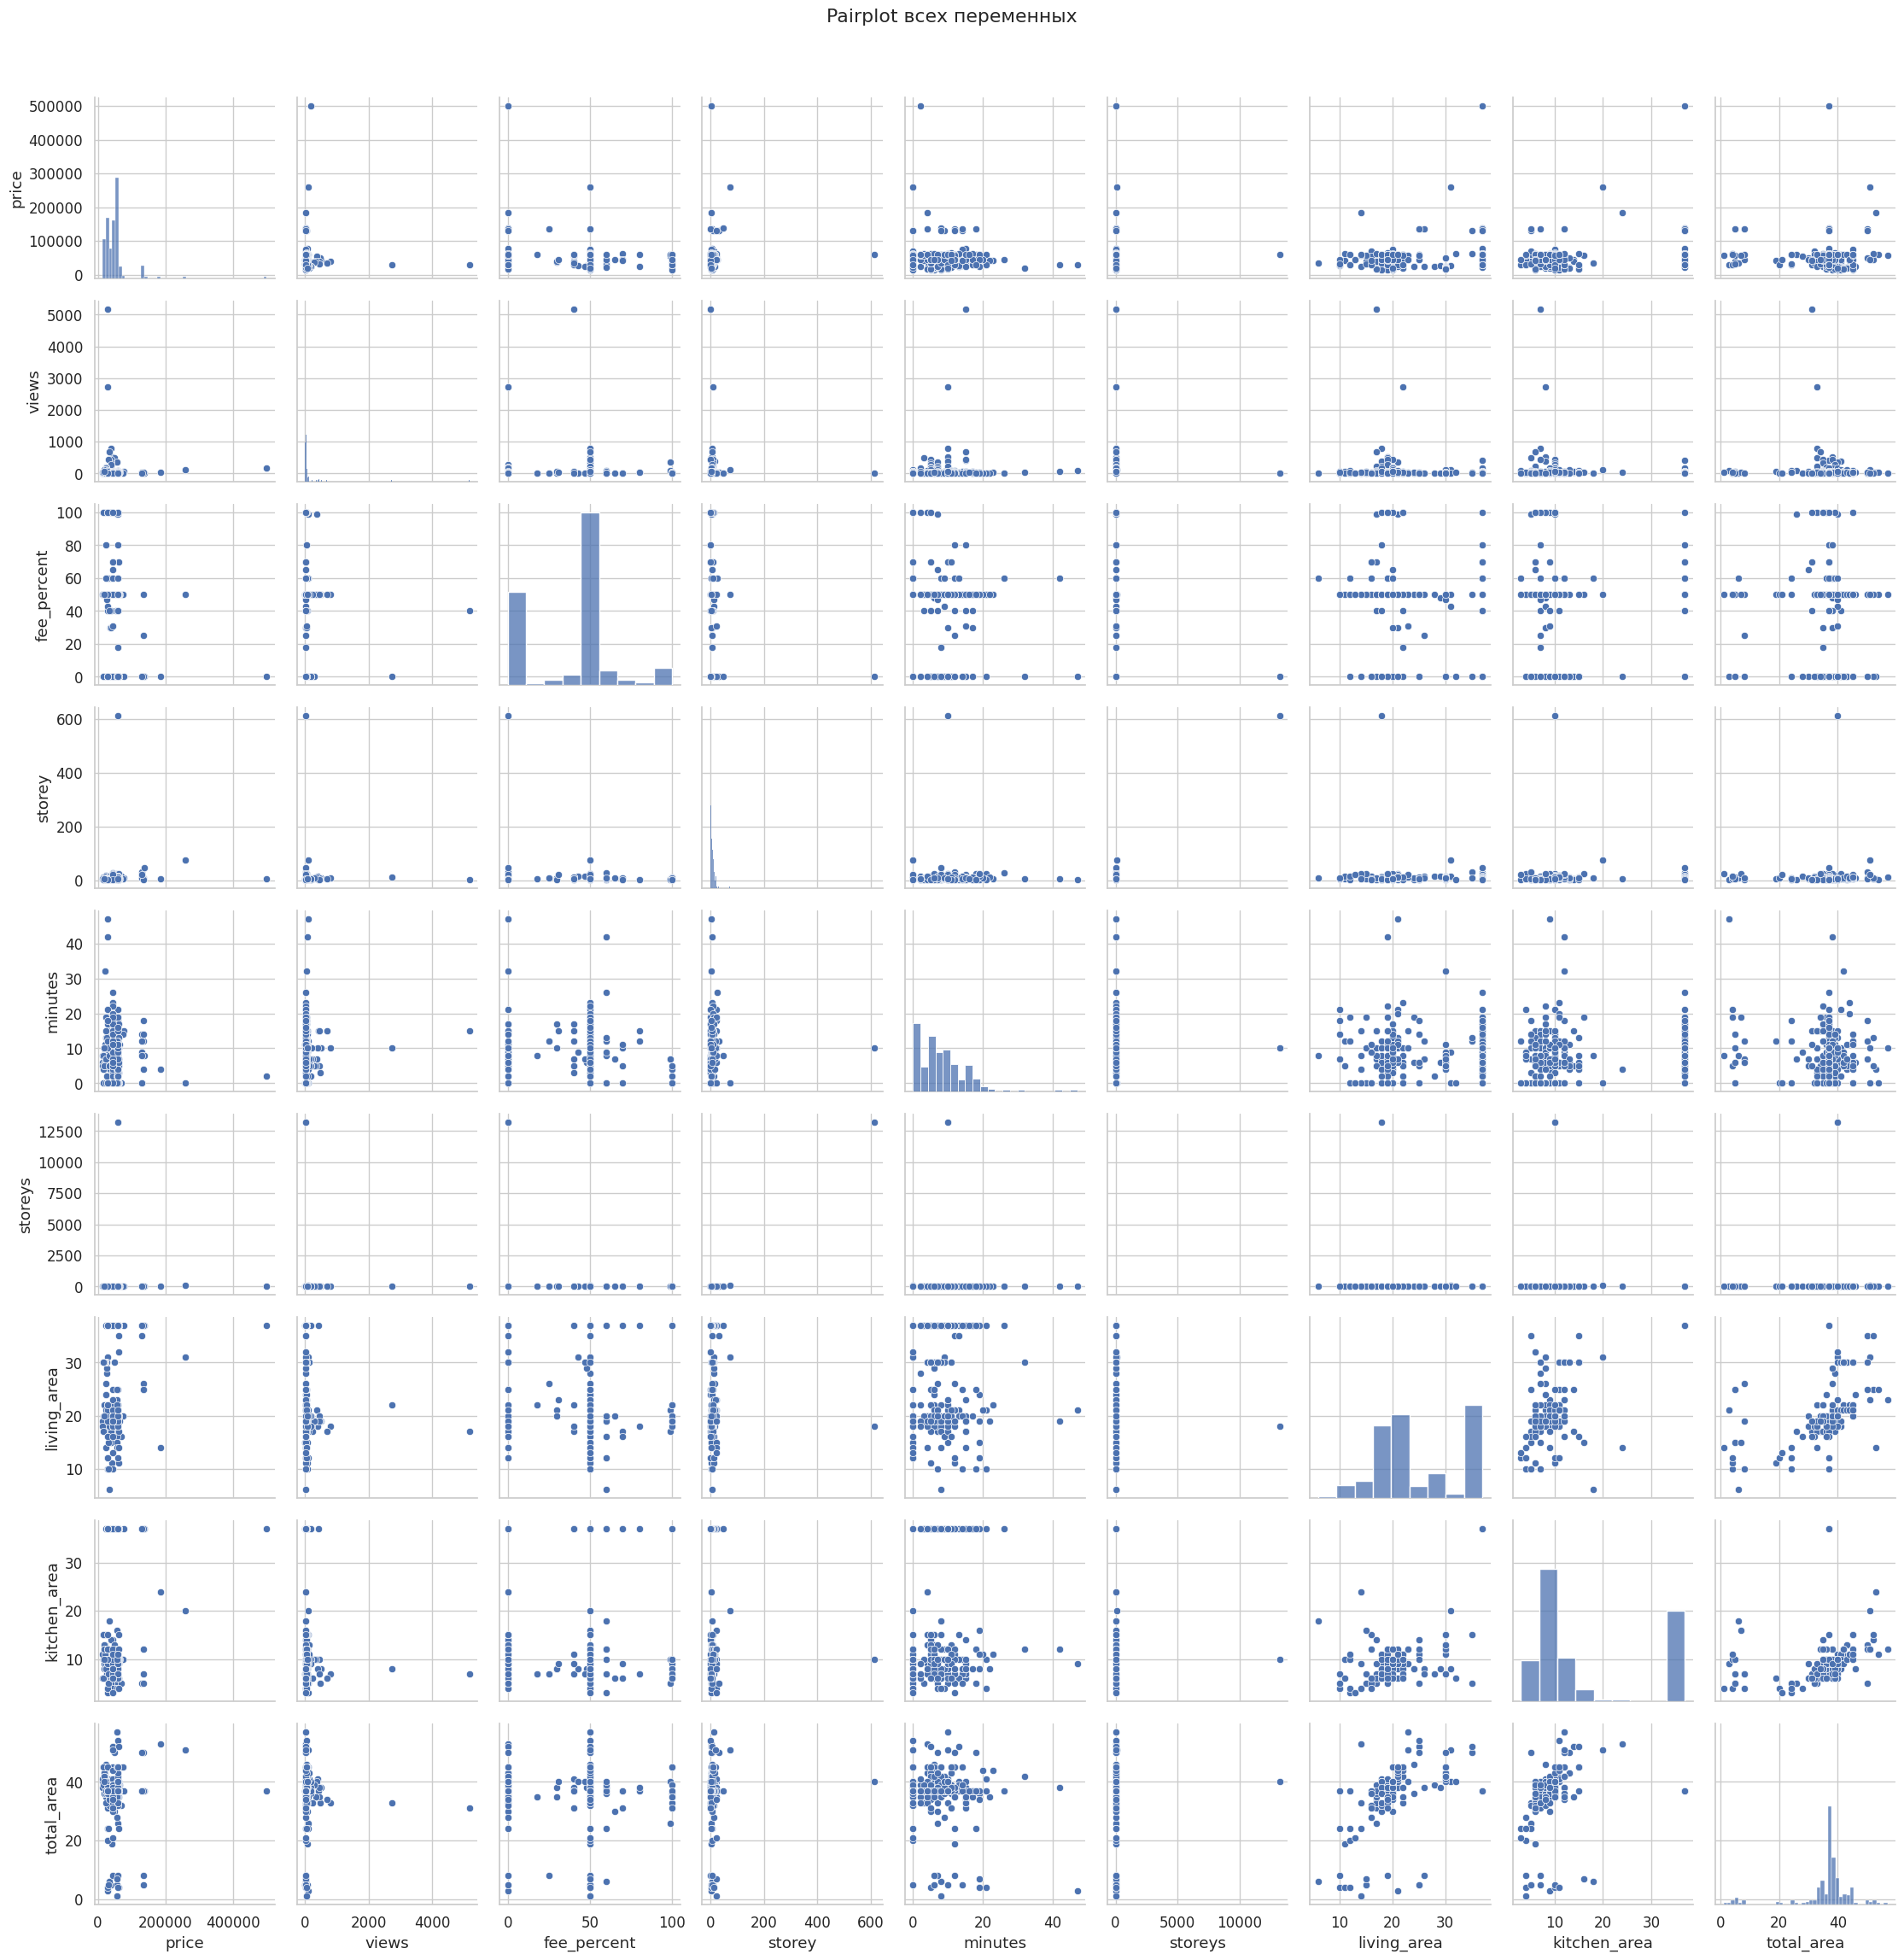

In [84]:
sns.pairplot(df)
plt.suptitle('Pairplot всех переменных', y=1.02)
plt.tight_layout()
plt.show()

#### 2.10. Boxplot цены аренды (2 балла)

Нарисуйте boxplot переменной price.

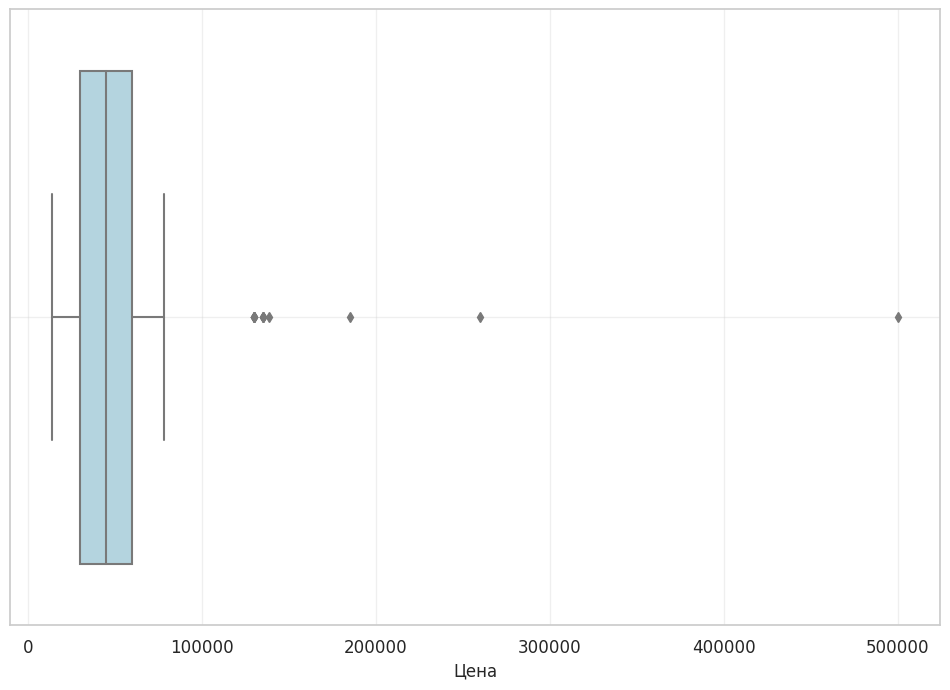

In [87]:
plt.figure(figsize=(12, 8))
sns.boxplot(x=df['price'], color='lightblue')

plt.xlabel('Цена', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

#### 2.11. Дополнительная визуализация (2 балла)

Нарисуйте любой график, который считаете красивым и нужным (а вы слышлаи про lmplot?).

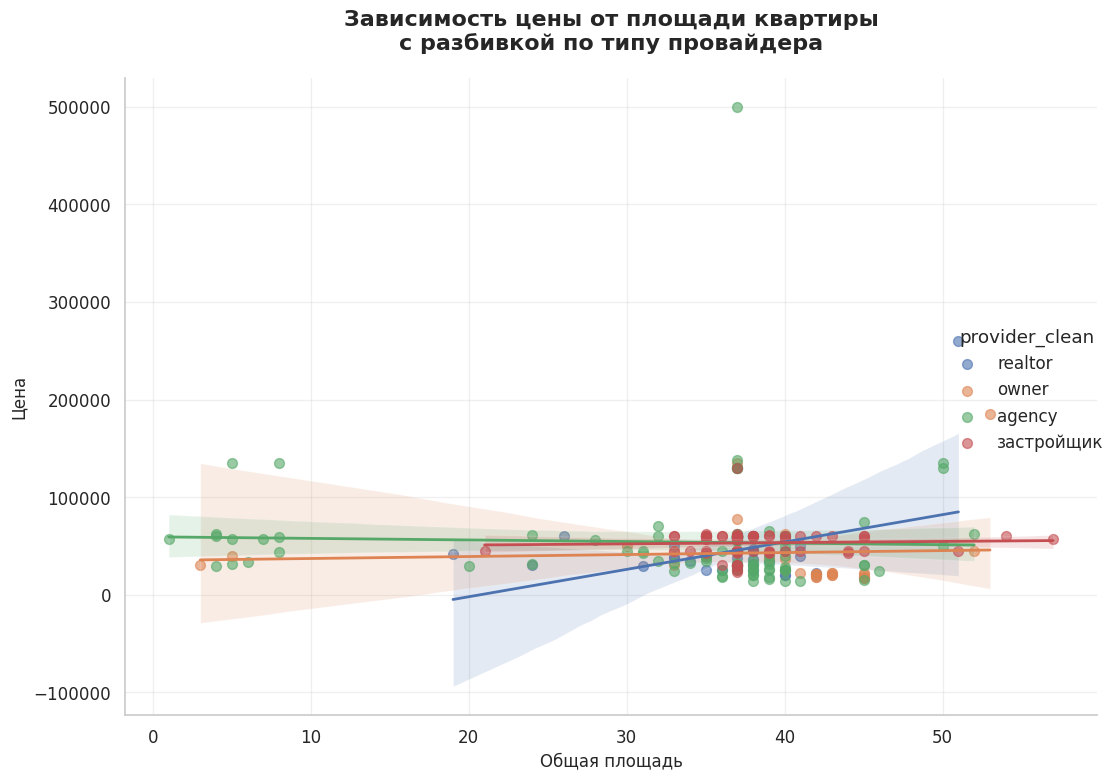

In [90]:
df['provider_clean'] = df['provider'].str.strip().str.lower()

sns.lmplot(data=df, x='total_area', y='price', 
           hue='provider_clean',
           height=8, 
           aspect=1.2,
           scatter_kws={'alpha': 0.6, 's': 50},
           line_kws={'linewidth': 2})

plt.title('Зависимость цены от площади квартиры\nс разбивкой по типу провайдера', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Общая площадь', fontsize=12)
plt.ylabel('Цена', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2.12. Анализ визуализаций (2 балла)

Какие выводы можно сделать из визуализаций 7-11?

> Ответ текстом

Цены в основном находится в диапазоне от 30 до 60 тысяч рублей. Стоимость растет с увеличением комнат. В большинстве случаев дорога до метро находится в диапазоне от 0 до 20 минут, цена в этом диапазоне примерно одинаковая.

#### 2.13. Корреляционный анализ (3 балла)

Постройте таблицу корреляций и тепловую карту числовых переменных. Между какими переменными наблюдается линейная связь?

,price,views,fee_percent,storey,minutes,storeys,living_area,kitchen_area,total_area
price,1.000000,-0.046706,-0.159946,0.070441,-0.074924,0.018541,0.211085,0.243515,0.006046
views,-0.046706,1.000000,-0.026805,-0.019725,0.078572,-0.013235,-0.103415,-0.106179,-0.037596
fee_percent,-0.159946,-0.026805,1.000000,-0.087791,-0.043229,-0.089446,-0.287182,-0.217804,-0.049272
storey,0.070441,-0.019725,-0.087791,1.000000,0.027628,0.982579,-0.048015,-0.040404,0.039210
minutes,-0.074924,0.078572,-0.043229,0.027628,1.000000,0.018024,-0.016318,-0.006020,-0.142629
storeys,0.018541,-0.013235,-0.089446,0.982579,0.018024,1.000000,-0.051725,-0.034357,0.027002
living_area,0.211085,-0.103415,-0.287182,-0.048015,-0.016318,-0.051725,1.000000,0.885334,0.314532
kitchen_area,0.243515,-0.106179,-0.217804,-0.040404,-0.006020,-0.034357,0.885334,1.000000,0.142474
total_area,0.006046,-0.037596,-0.049272,0.039210,-0.142629,0.027002,0.314532,0.142474,1.000000


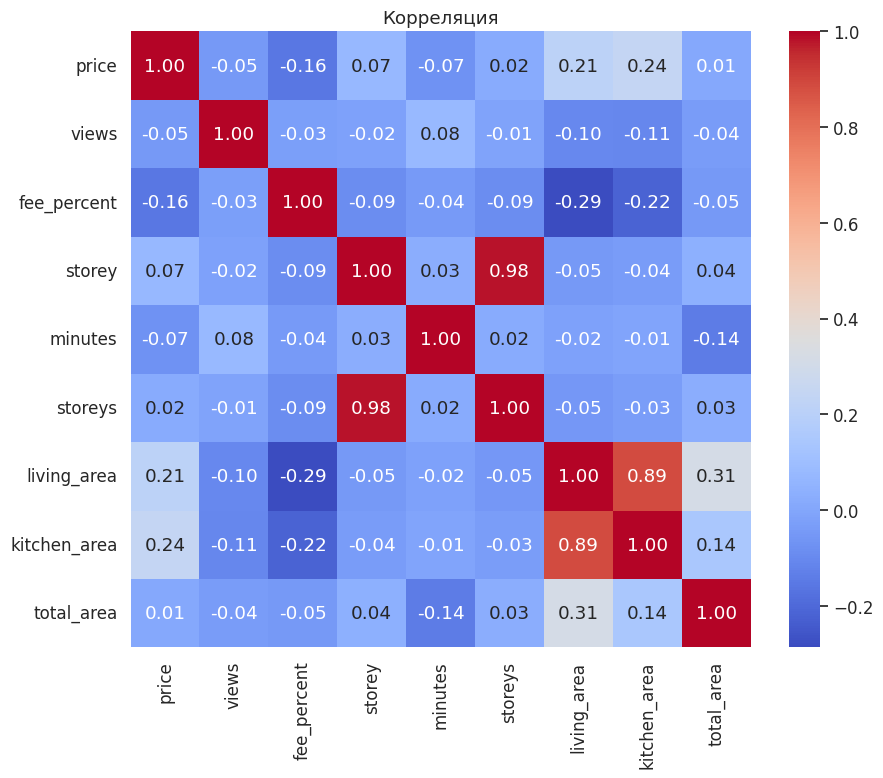

In [93]:
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

display(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляция")
plt.show()

> Ответ текстом

Главная диагональ не учитвается, потому что значения коррелируют сами с собой. Поэтому наибольшая линейная связь
наблюдается между значениями storeys-story, kitchen area-living area.